<a href="https://colab.research.google.com/github/ayushi226-del/churnzero/blob/main/churn_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/ChurnZero/ChurnZero_Dataset_v1.csv'
df = pd.read_csv(file_path)
display(df.head())

,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/ChurnZero/ChurnZero_Dataset_v1.csv'
df = pd.read_csv(file_path)
display(df.tail())

,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
8096,141097,0,46,Female,Married,High School,4,Salaried,52564,Middle,...,0,Not Aware,Negative,4146,0.018,0.100,100839.0,31,0.2966,62.2
8097,141098,0,52,Female,Married,High School,1,Business Owner,18000,Low,...,1,Not Aware,Neutral,1154,0.429,0.528,67323.0,22,2.1887,45.1
8098,141099,1,61,Female,Single,Graduate,0,Business Owner,42192,Lower-Middle,...,0,Low,Neutral,2725,0.017,0.151,6378.0,15,0.0000,56.3
8099,141100,0,43,Female,Married,Graduate,3,Salaried,43338,Lower-Middle,...,0,Not Aware,Negative,4609,0.822,0.772,51965.0,25,0.0000,60.5
8100,141101,0,52,Female,Single,Uneducated,3,Retired,32970,Lower-Middle,...,1,Low,Positive,2993,0.622,0.597,48897.0,32,0.4826,39.2


# New

In [ ]:
!pip install -q missingno imbalanced-learn

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from scipy import stats

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ─── Adjust path if your folder structure differs ───
FILE_PATH = '/content/drive/MyDrive/ChurnZero/ChurnZero_Dataset_v1.csv'

df = pd.read_csv(FILE_PATH)
df_original = df.copy()   # keep an untouched backup

print(f'✅ Dataset loaded — {df.shape[0]:,} rows × {df.shape[1]} columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded — 8,101 rows × 98 columns


### Adding New Text Here

  Target column  : churn
  Unique values  : [np.int64(0), np.int64(1)]
  Type           : int64


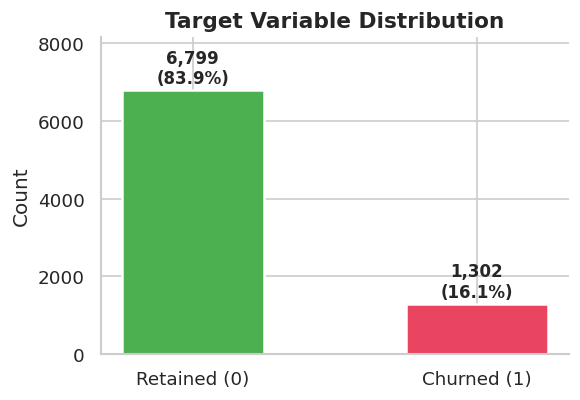

⚠️  Class imbalance ratio  →  5.2:1  (Retained : Churned)


In [ ]:
TARGET = 'churn'

print('='*50)
print(f'  Target column  : {TARGET}')
print(f'  Unique values  : {sorted(df[TARGET].unique())}')
print(f'  Type           : {df[TARGET].dtype}')
print('='*50)

# Class distribution
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['Retained (0)', 'Churned (1)'], counts.values,
              color=['#4CAF50', '#e94560'], edgecolor='white', linewidth=1.5,
              width=0.5)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 60,
            f'{bar.get_height():,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Target Variable Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'⚠️  Class imbalance ratio  →  {counts[0]/counts[1]:.1f}:1  (Retained : Churned)')

Total numeric features : 82

Top 20 features by |correlation| with churn:
total_digital_logins            0.5078
unresolved_complaint_count      0.4943
balance_decline_percentage      0.4559
complaint_resolution_time       0.4483
mobile_app_login_count          0.4273
cash_withdrawal_count           0.4258
email_open_rate                 0.4111
last_campaign_response_days     0.4048
emi_payment_delay_count         0.4032
service_request_count           0.3922
last_contacted_days             0.3837
total_trans_count               0.3725
retention_offer_received        0.3720
monthly_transaction_count       0.3676
minimum_due_paid_flag           0.3671
upi_transaction_count           0.3441
last_login_days                 0.3426
escalation_count                0.3375
debit_card_transaction_count    0.3348
website_login_count             0.3326


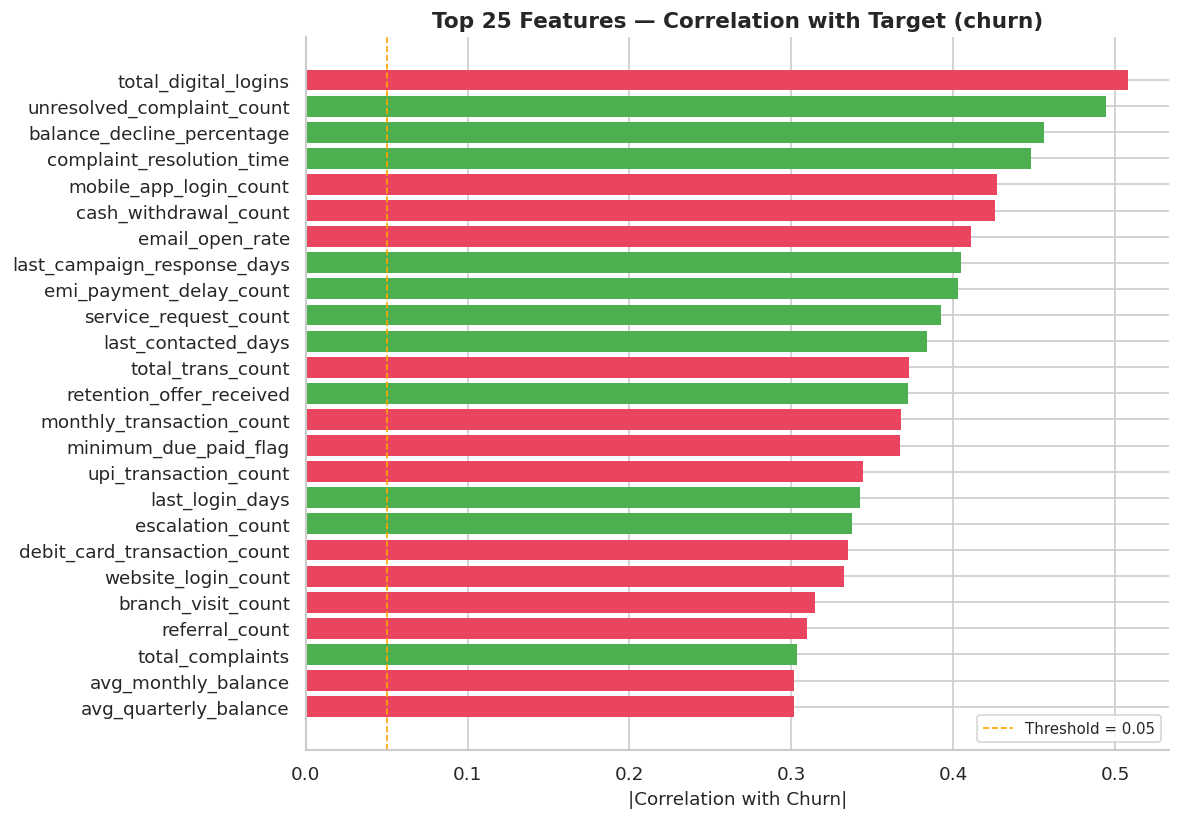


Numeric features selected (|corr| ≥ 0.03): 58


In [ ]:
# ── Correlation with target (numeric columns) ─────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

corr_with_target = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr_abs         = corr_with_target.abs().sort_values(ascending=False)

print(f'Total numeric features : {len(num_cols)}')
print(f'\nTop 20 features by |correlation| with churn:')
print(corr_abs.head(20).round(4).to_string())

# ── Plot top 25 correlations ──────────────────────────────────────────────
top25 = corr_abs.head(25)
colors = ['#4CAF50' if corr_with_target[c] > 0 else '#e94560' for c in top25.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1], edgecolor='none')
ax.set_xlabel('|Correlation with Churn|', fontsize=11)
ax.set_title('Top 25 Features — Correlation with Target (churn)', fontweight='bold', fontsize=13)
ax.axvline(0.05, color='orange', linestyle='--', linewidth=1, label='Threshold = 0.05')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── Keep features with |corr| >= 0.03 ────────────────────────────────────
CORR_THRESHOLD   = 0.03
selected_numeric = corr_abs[corr_abs >= CORR_THRESHOLD].index.tolist()
print(f'\nNumeric features selected (|corr| ≥ {CORR_THRESHOLD}): {len(selected_numeric)}')

In [ ]:
cols_before = df.shape[1]

# ── 1. ID / index columns ─────────────────────────────────────────────────
id_cols = [c for c in df.columns if 'id' in c.lower() or c.lower() == 'index']

# ── 2. Near-constant columns (>98% same value) ────────────────────────────
near_const = [c for c in df.select_dtypes(include=np.number).columns
              if df[c].value_counts(normalize=True).iloc[0] >= 0.98
              and c != TARGET]

# ── 3. Derived / leakage-risk columns already captured by others ──────────
# (avg_quarterly_balance is captured by avg_monthly_balance;
#  credit_utilization_3m_avg & 6m_avg are captured by credit_utilization_ratio)
redundant = ['avg_quarterly_balance', 'credit_utilization_3m_avg',
             'credit_utilization_6m_avg', 'monthly_income_estimate']
redundant = [c for c in redundant if c in df.columns]

# ── 4. Smoothed columns (already used for denoising, original kept) ───────
smoothed_cols = [c for c in df.columns if c.endswith('_smoothed')]

drop_all = list(set(id_cols + near_const + redundant + smoothed_cols))

print('Columns being dropped:')
print(f'  ID columns       : {id_cols}')
print(f'  Near-constant    : {near_const}')
print(f'  Redundant        : {redundant}')
print(f'  Smoothed helpers : {smoothed_cols}')
print(f'  Total to drop    : {len(drop_all)}')

df.drop(columns=drop_all, inplace=True, errors='ignore')

print(f'\nColumns : {cols_before} → {df.shape[1]}  (removed {cols_before - df.shape[1]})')
print('✅ Unnecessary columns removed.')

Columns being dropped:
  ID columns       : ['customer_id', 'minimum_due_paid_flag']
  Near-constant    : ['credit_card_flag', 'mobile_banking_active_flag']
  Redundant        : ['avg_quarterly_balance', 'credit_utilization_3m_avg', 'credit_utilization_6m_avg', 'monthly_income_estimate']
  Smoothed helpers : []
  Total to drop    : 8

Columns : 98 → 90  (removed 8)
✅ Unnecessary columns removed.


In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print('='*50)
print(f'  Feature matrix X : {X.shape[0]:,} rows × {X.shape[1]} columns')
print(f'  Label vector   y : {y.shape[0]:,} values')
print(f'  Target dtype     : {y.dtype}')
print('='*50)

# ── Column type breakdown inside X ───────────────────────────────────────
x_num = X.select_dtypes(include=np.number).columns.tolist()
x_cat = X.select_dtypes(include=['object','string']).columns.tolist()

print(f'\nInside X:')
print(f'  Numeric columns     : {len(x_num)}')
print(f'  Categorical columns : {len(x_cat)}  → {x_cat}')

print('\n✅ X and y successfully separated.')

  Feature matrix X : 8,101 rows × 89 columns
  Label vector   y : 8,101 values
  Target dtype     : int64

Inside X:
  Numeric columns     : 74
  Categorical columns : 15  → ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']

✅ X and y successfully separated.


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
cat_cols  = X_encoded.select_dtypes(include=['object','string']).columns.tolist()

# ── Ordinal columns — Label Encoding (natural order exists) ───────────────
ORDINAL_MAP = {
    'education_level'  : ['uneducated', 'high school', 'college',
                          'graduate', 'post-graduate', 'doctorate'],
    'income_band'      : ['low', 'lower middle', 'middle',
                          'upper middle', 'high', 'very high'],
    'city_tier'        : ['tier 3', 'tier 2', 'tier 1'],
}

print('── Ordinal Encoding ──────────────────────────────────')
for col, order in ORDINAL_MAP.items():
    if col not in X_encoded.columns:
        continue
    unique_vals = X_encoded[col].str.lower().str.strip().unique()
    # Build map only for values actually present
    mapping = {v: i for i, v in enumerate(order) if v in unique_vals}
    X_encoded[col] = (X_encoded[col].str.lower().str.strip()
                      .map(mapping)
                      .fillna(-1).astype(int))
    print(f'  {col:22s}: {mapping}')

# ── Nominal columns — One-Hot Encoding (no natural order) ────────────────
nominal_cols = [c for c in cat_cols if c not in ORDINAL_MAP]
print(f'\n── One-Hot Encoding ──────────────────────────────────')
print(f'  Columns : {nominal_cols}')

X_encoded = pd.get_dummies(X_encoded, columns=nominal_cols,
                            drop_first=True, dtype='int8')

# ── Summary ───────────────────────────────────────────────────────────────
remaining_cats = X_encoded.select_dtypes(include=['object','string']).columns.tolist()
print(f'\nShape after encoding : {X_encoded.shape}')
print(f'Remaining text cols  : {remaining_cats if remaining_cats else "None ✅"}')

# Quick peek at new OHE columns
new_ohe_cols = [c for c in X_encoded.columns if c not in X.columns]
print(f'New OHE columns added: {len(new_ohe_cols)}')
print('\n✅ Categorical encoding complete.')

── Ordinal Encoding ──────────────────────────────────
  education_level       : {'uneducated': 0, 'high school': 1, 'college': 2, 'graduate': 3, 'post-graduate': 4, 'doctorate': 5}
  income_band           : {'low': 0, 'middle': 2, 'high': 4}
  city_tier             : {'tier 3': 0, 'tier 2': 1, 'tier 1': 2}

── One-Hot Encoding ──────────────────────────────────
  Columns : ['gender', 'marital_status', 'occupation_type', 'income_category', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']

Shape after encoding : (8101, 116)
Remaining text cols  : None ✅
New OHE columns added: 39

✅ Categorical encoding complete.


Columns to scale     : 58
Columns kept as-is   : 58  (binary/ordinal)

Scaling comparison (first 6 continuous columns):
                         Min (before)  Max (before)  Min (after)  Max (after)
age                             26.00         73.00        -1.82         2.45
dependent_count                  0.00          5.00        -1.00         1.50
annual_income                18000.00     241318.00        -0.74         4.21
tenure_months                   13.00         56.00        -2.88         2.50
number_of_products               1.00          6.00        -1.50         1.00
customer_lifetime_value        733.48      88861.82        -0.87         6.46


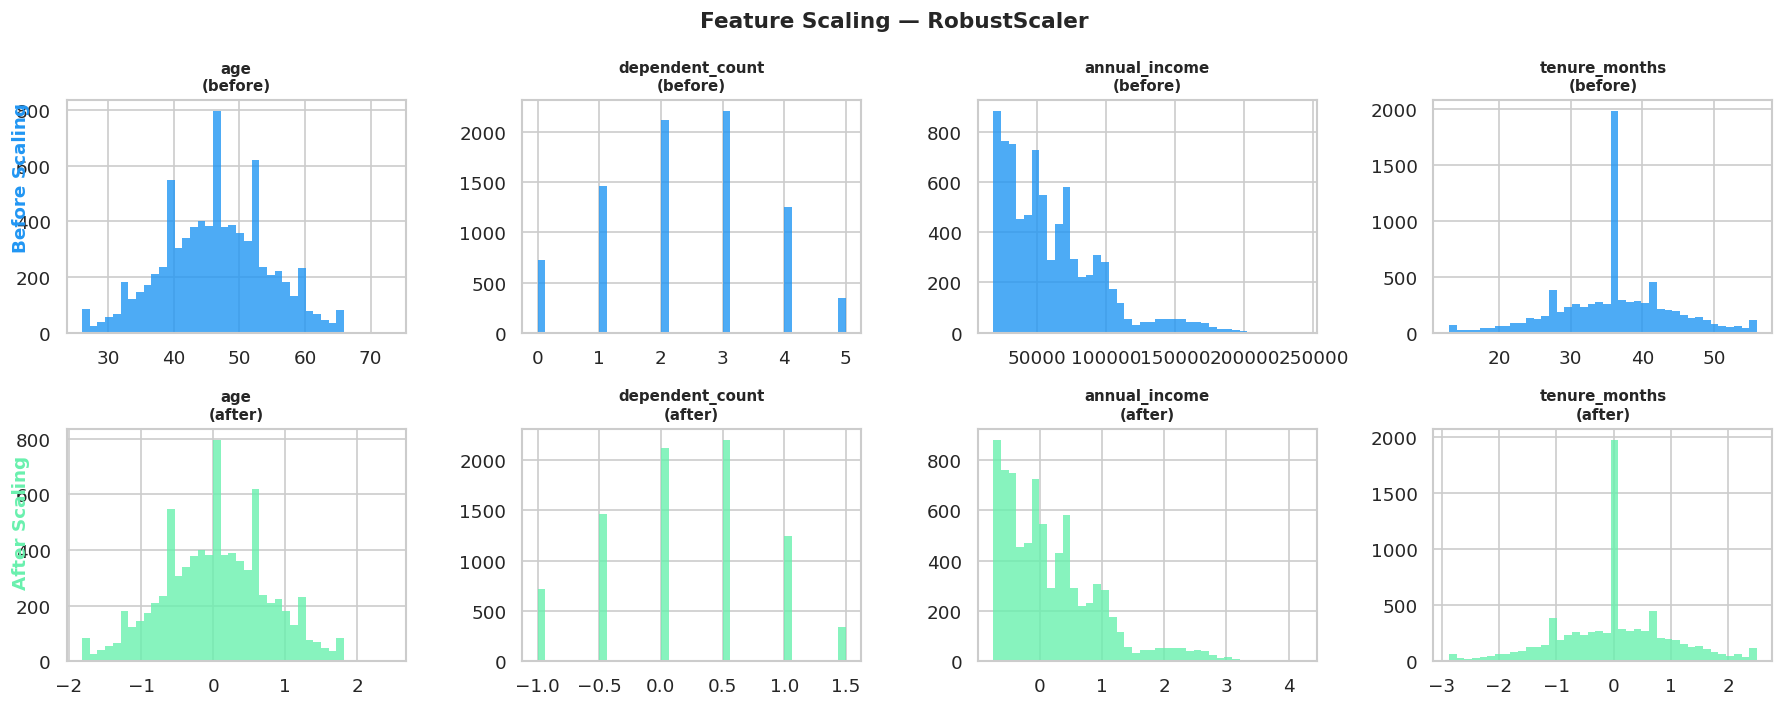

✅ Feature scaling complete. Scaler object saved for inference.


In [ ]:
from sklearn.preprocessing import RobustScaler

X_scaled = X_encoded.copy()

# ── Identify columns that NEED scaling ────────────────────────────────────
# Skip: binary flags (0/1), OHE columns, ordinal-encoded columns
skip_cols  = [c for c in X_scaled.columns if X_scaled[c].nunique() <= 2]
skip_cols += list(ORDINAL_MAP.keys())
scale_cols = [c for c in X_scaled.select_dtypes(include=np.number).columns
              if c not in skip_cols]

print(f'Columns to scale     : {len(scale_cols)}')
print(f'Columns kept as-is   : {len(skip_cols)}  (binary/ordinal)')

# ── Before scaling — show value ranges ───────────────────────────────────
range_before = X_scaled[scale_cols[:6]].agg(['min','max']).T
range_before.columns = ['Min (before)', 'Max (before)']

# ── Apply RobustScaler (best for data with residual outliers) ─────────────
scaler = RobustScaler()
X_scaled[scale_cols] = scaler.fit_transform(X_scaled[scale_cols])

# ── After scaling — show new ranges ──────────────────────────────────────
range_after = X_scaled[scale_cols[:6]].agg(['min','max']).T
range_after.columns  = ['Min (after)', 'Max (after)']

comparison = pd.concat([range_before, range_after], axis=1).round(2)
print('\nScaling comparison (first 6 continuous columns):')
print(comparison.to_string())

# ── Visual comparison ─────────────────────────────────────────────────────
demo_cols = scale_cols[:4]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i, col in enumerate(demo_cols):
    axes[0, i].hist(X_encoded[col], bins=40, color='#2196F3', edgecolor='none', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(before)', fontsize=9, fontweight='bold')
    axes[1, i].hist(X_scaled[col],  bins=40, color='#69f0ae', edgecolor='none', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(after)',  fontsize=9, fontweight='bold')

fig.text(0.01, 0.75, 'Before Scaling', va='center', rotation='vertical',
         fontweight='bold', color='#2196F3', fontsize=11)
fig.text(0.01, 0.27, 'After Scaling',  va='center', rotation='vertical',
         fontweight='bold', color='#69f0ae', fontsize=11)
plt.suptitle('Feature Scaling — RobustScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('✅ Feature scaling complete. Scaler object saved for inference.')

In [ ]:
print('━'*55)
print('  📋  DATASET VERIFICATION REPORT')
print('━'*55)

checks = []

# 1. Shape
print(f'\n  Feature matrix X : {X_scaled.shape[0]:,} rows × {X_scaled.shape[1]} columns')
print(f'  Label vector   y : {y.shape[0]:,} values')
checks.append(('Row counts match', X_scaled.shape[0] == y.shape[0]))

# 2. No missing values
null_x = X_scaled.isnull().sum().sum()
null_y = y.isnull().sum()
print(f'\n  Missing in X     : {null_x}')
print(f'  Missing in y     : {null_y}')
checks.append(('No nulls in X', null_x == 0))
checks.append(('No nulls in y', null_y == 0))

# 3. No infinite values
inf_x = np.isinf(X_scaled.select_dtypes(include=np.number)).sum().sum()
print(f'  Infinite values  : {inf_x}')
checks.append(('No infinite values', inf_x == 0))

# 4. All columns numeric
non_num = X_scaled.select_dtypes(exclude=np.number).columns.tolist()
print(f'  Non-numeric cols : {non_num if non_num else "None"}')
checks.append(('All features numeric', len(non_num) == 0))

# 5. Target is binary
target_vals = sorted(y.unique())
print(f'  Target values    : {target_vals}')
checks.append(('Target is binary [0,1]', target_vals == [0, 1]))

# 6. No duplicate rows in X
dupes = X_scaled.duplicated().sum()
print(f'  Duplicate rows   : {dupes}')
checks.append(('No duplicate rows', dupes == 0))

# ── Print pass/fail summary ───────────────────────────────────────────────
print('\n  Check Results:')
all_passed = True
for name, passed in checks:
    status = '  ✅ PASS' if passed else '  ❌ FAIL'
    print(f'    {status}  {name}')
    if not passed:
        all_passed = False

print('\n' + '━'*55)
if all_passed:
    print('  🎯  ALL CHECKS PASSED — Dataset is model-ready!')
else:
    print('  ⚠️   SOME CHECKS FAILED — Review the issues above.')
print('━'*55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋  DATASET VERIFICATION REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Feature matrix X : 8,101 rows × 116 columns
  Label vector   y : 8,101 values

  Missing in X     : 4541
  Missing in y     : 0
  Infinite values  : 0
  Non-numeric cols : None
  Target values    : [np.int64(0), np.int64(1)]
  Duplicate rows   : 0

  Check Results:
      ✅ PASS  Row counts match
      ❌ FAIL  No nulls in X
      ✅ PASS  No nulls in y
      ✅ PASS  No infinite values
      ✅ PASS  All features numeric
      ✅ PASS  Target is binary [0,1]
      ✅ PASS  No duplicate rows

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ⚠️   SOME CHECKS FAILED — Review the issues above.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


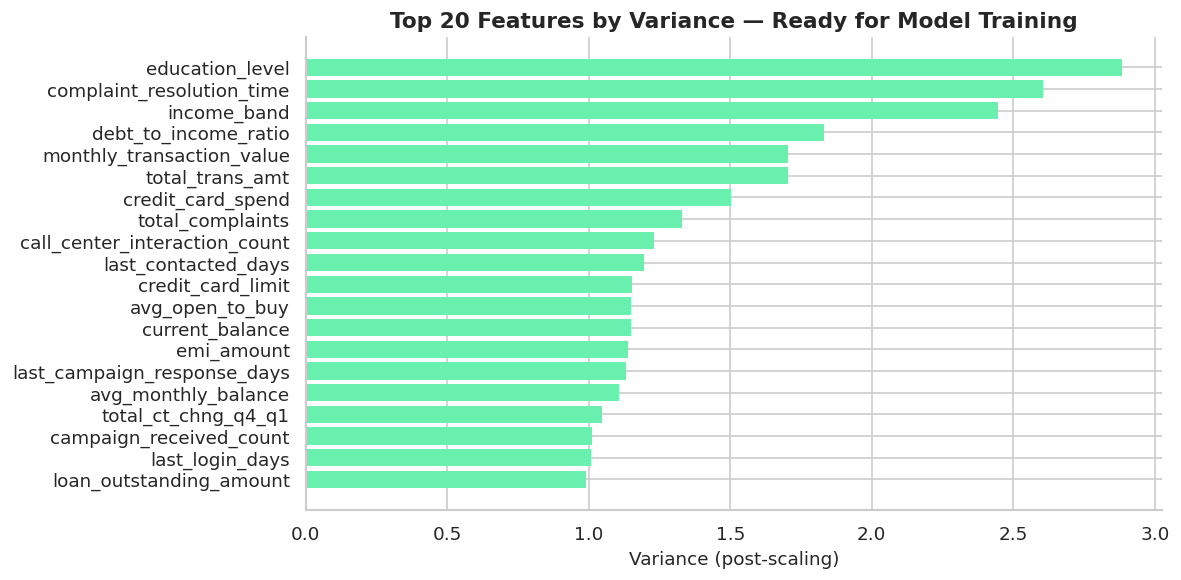


Final X shape : (8101, 116)
Final y shape : (8101,)


In [ ]:
# ── Final feature importance preview (variance proxy) ─────────────────────
variances = X_scaled.var().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(variances.index[::-1], variances.values[::-1],
        color='#69f0ae', edgecolor='none')
ax.set_xlabel('Variance (post-scaling)', fontsize=11)
ax.set_title('Top 20 Features by Variance — Ready for Model Training',
             fontweight='bold', fontsize=13)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'\nFinal X shape : {X_scaled.shape}')
print(f'Final y shape : {y.shape}')

In [ ]:
import joblib

SAVE_DIR = '/content/drive/MyDrive/ChurnZero/'

# Save final feature + label CSV
df_final = X_scaled.copy()
df_final[TARGET] = y.values
df_final.to_csv(SAVE_DIR + 'ChurnZero_model_ready.csv', index=False)

# Save scaler for use during inference
joblib.dump(scaler, SAVE_DIR + 'robust_scaler.pkl')

print('✅ Files saved to Google Drive:')
print(f'   ChurnZero/ChurnZero_model_ready.csv  →  {df_final.shape[0]:,} × {df_final.shape[1]}')
print('   ChurnZero/robust_scaler.pkl')
print('\n🚀 Ready to train: Logistic Regression, XGBoost, or Random Forest.')
print('   Remember to use class_weight="balanced" or SMOTE for the 16% churn minority.')

✅ Files saved to Google Drive:
   ChurnZero/ChurnZero_model_ready.csv  →  8,101 × 117
   ChurnZero/robust_scaler.pkl

🚀 Ready to train: Logistic Regression, XGBoost, or Random Forest.
   Remember to use class_weight="balanced" or SMOTE for the 16% churn minority.


❌❌❌❌

# Understanding the Problem

In [ ]:
# ── Basic shape & dtypes ──────────────────────────────────────────────────
print('='*60)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print('='*60)
print('\nColumn data types:')
print(df.dtypes.value_counts())
print('\nFirst 5 rows:')
df.head()

  Rows    : 8,101
  Columns : 90

Column data types:
int64      55
float64    20
object     15
Name: count, dtype: int64

First 5 rows:


,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,income_category,...,upsell_offer_count,retention_offer_received,retention_offer_accepted,last_campaign_response_days,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,0,36,Female,Married,Unknown,0,Salaried,22256,Low,Less than $40K,...,0,1,1,8,0,Not Aware,Positive,33,0.0000,55.6
1,1,44,Male,Single,High School,3,Homemaker,66481,Middle,$60K - $80K,...,0,1,1,158,1,High,Positive,19,0.0000,54.5
2,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,$80K - $120K,...,2,0,0,3,0,Low,Positive,31,0.0000,43.0
3,0,36,Female,Married,Graduate,2,Retired,26735,Low,Less than $40K,...,1,0,0,15,0,Medium,Neutral,29,0.5135,57.2
4,0,50,Male,Single,Graduate,1,Salaried,165387,High,$120K +,...,0,0,0,60,1,Low,Positive,22,0.2289,56.1


# Target variable overview

TARGET  |  Count  |  Percentage
--------------------------------------
  Retained |  6,799  |   83.9%
  Churned  |  1,302  |   16.1%


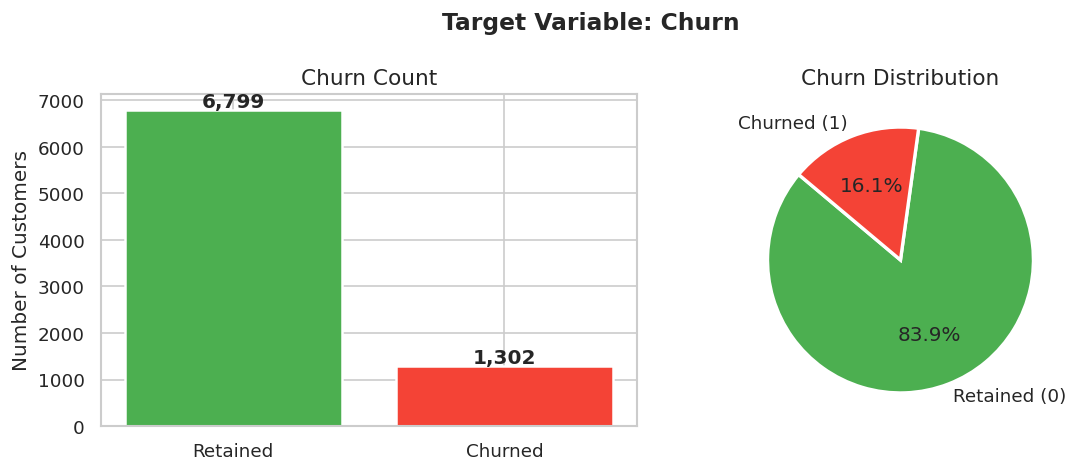

⚠️  Class Imbalance Detected — Churned customers are only ~16%


In [ ]:
# ── Target variable overview ──────────────────────────────────────────────
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print('TARGET  |  Count  |  Percentage')
print('-'*38)
for label in [0, 1]:
    tag = 'Retained' if label == 0 else 'Churned '
    print(f'  {tag} |  {churn_counts[label]:5,}  |  {churn_pct[label]:5.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Distribution')
plt.suptitle('Target Variable: Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('⚠️  Class Imbalance Detected — Churned customers are only ~16%')

# Column Categories

In [ ]:
# ── Column categories ─────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Numeric  columns : {len(num_cols)}')
print(f'Categorical cols : {len(cat_cols)}')
print(f'\nCategorical columns:\n{cat_cols}')

Numeric  columns : 75
Categorical cols : 15

Categorical columns:
['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']


# Statistical summary

In [ ]:
# ── Statistical summary ───────────────────────────────────────────────────
print('Numeric summary (first 10 columns):')
df[num_cols[:10]].describe().T.style.background_gradient(cmap='Blues', axis=1)

Numeric summary (first 10 columns):


,count,mean,std,min,25%,50%,75%,max
churn,8101.000000,0.160721,0.367296,0.000000,0.000000,0.000000,0.000000,1.000000
age,8101.000000,46.390199,7.985385,26.000000,41.000000,46.000000,52.000000,73.000000
dependent_count,8101.000000,2.349093,1.297993,0.000000,1.000000,2.000000,3.000000,5.000000
annual_income,8101.000000,60052.874583,35422.472020,18000.000000,31813.000000,51592.000000,76910.000000,241318.000000
tenure_months,8101.000000,36.005555,7.934351,13.000000,32.000000,36.000000,40.000000,56.000000
number_of_products,8101.000000,3.810023,1.554787,1.000000,3.000000,4.000000,5.000000,6.000000
customer_lifetime_value,8101.000000,14102.415556,10603.985218,733.480000,6563.310000,11166.440000,18585.960000,88861.820000
loyalty_program_member,8101.000000,0.542772,0.498198,0.000000,0.000000,1.000000,1.000000,1.000000
referral_count,8101.000000,1.046537,1.076428,0.000000,0.000000,1.000000,2.000000,7.000000
last_contacted_days,8101.000000,43.220096,50.264066,1.000000,11.000000,27.000000,57.000000,365.000000


# EDA and Visualisation

Missing value overview:
app_rating_given    4541
dtype: int64


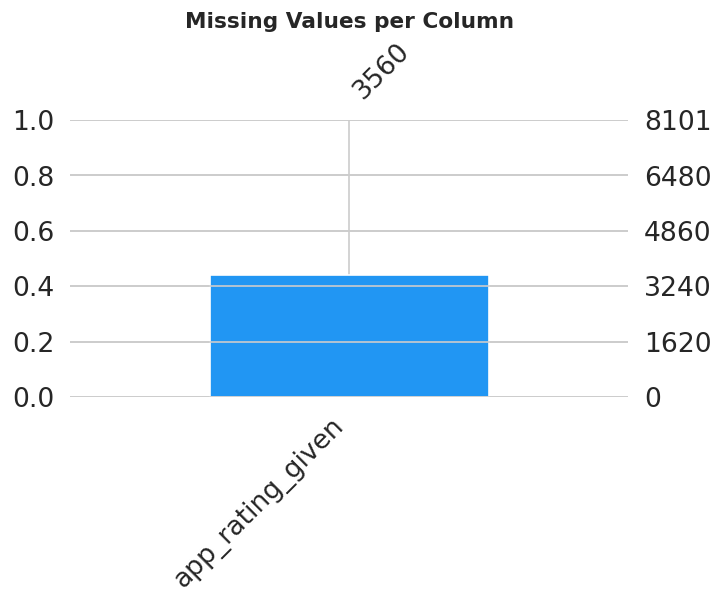

In [ ]:
# ── 3a. Missing value heatmap ─────────────────────────────────────────────
print('Missing value overview:')
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(6, 3))
msno.bar(df[missing.index], color='#2196F3', figsize=(6, 3))
plt.title('Missing Values per Column', fontweight='bold')
plt.show()


# Age & Tenure distribution by Churn




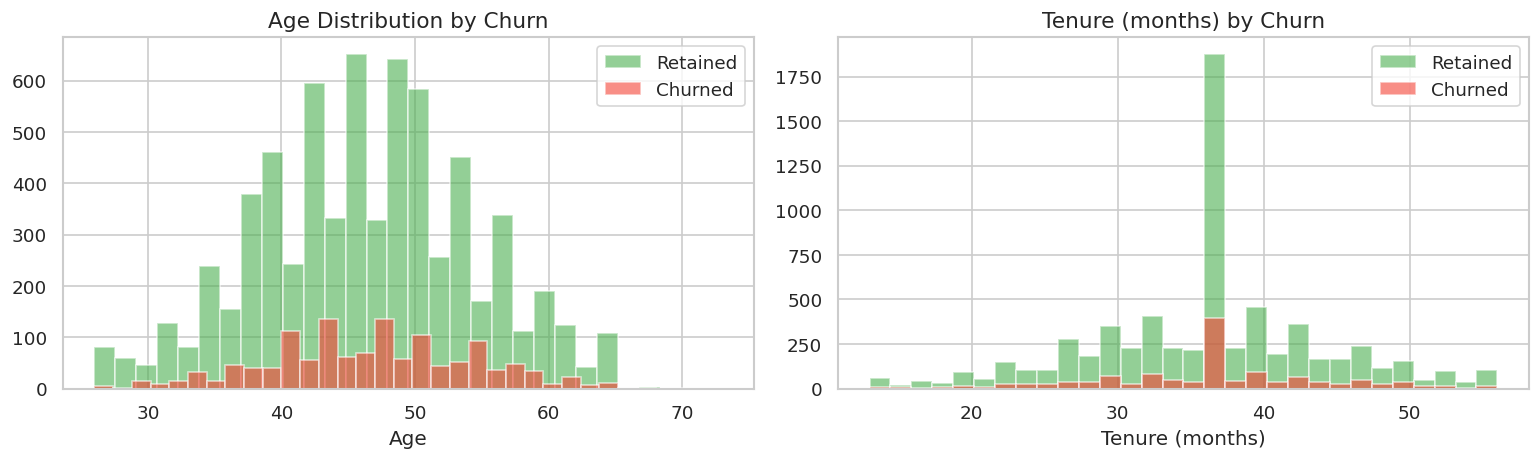

In [ ]:
# ── 3b. Age & Tenure distribution by Churn ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
    subset = df[df['churn'] == label]
    axes[0].hist(subset['age'], bins=30, alpha=0.6, color=color,
                 label='Retained' if label == 0 else 'Churned', edgecolor='white')
    axes[1].hist(subset['tenure_months'], bins=30, alpha=0.6, color=color,
                 label='Retained' if label == 0 else 'Churned', edgecolor='white')

axes[0].set_title('Age Distribution by Churn')
axes[0].set_xlabel('Age'); axes[0].legend()
axes[1].set_title('Tenure (months) by Churn')
axes[1].set_xlabel('Tenure (months)'); axes[1].legend()
plt.tight_layout()
plt.show()

# Categorical features vs Churn

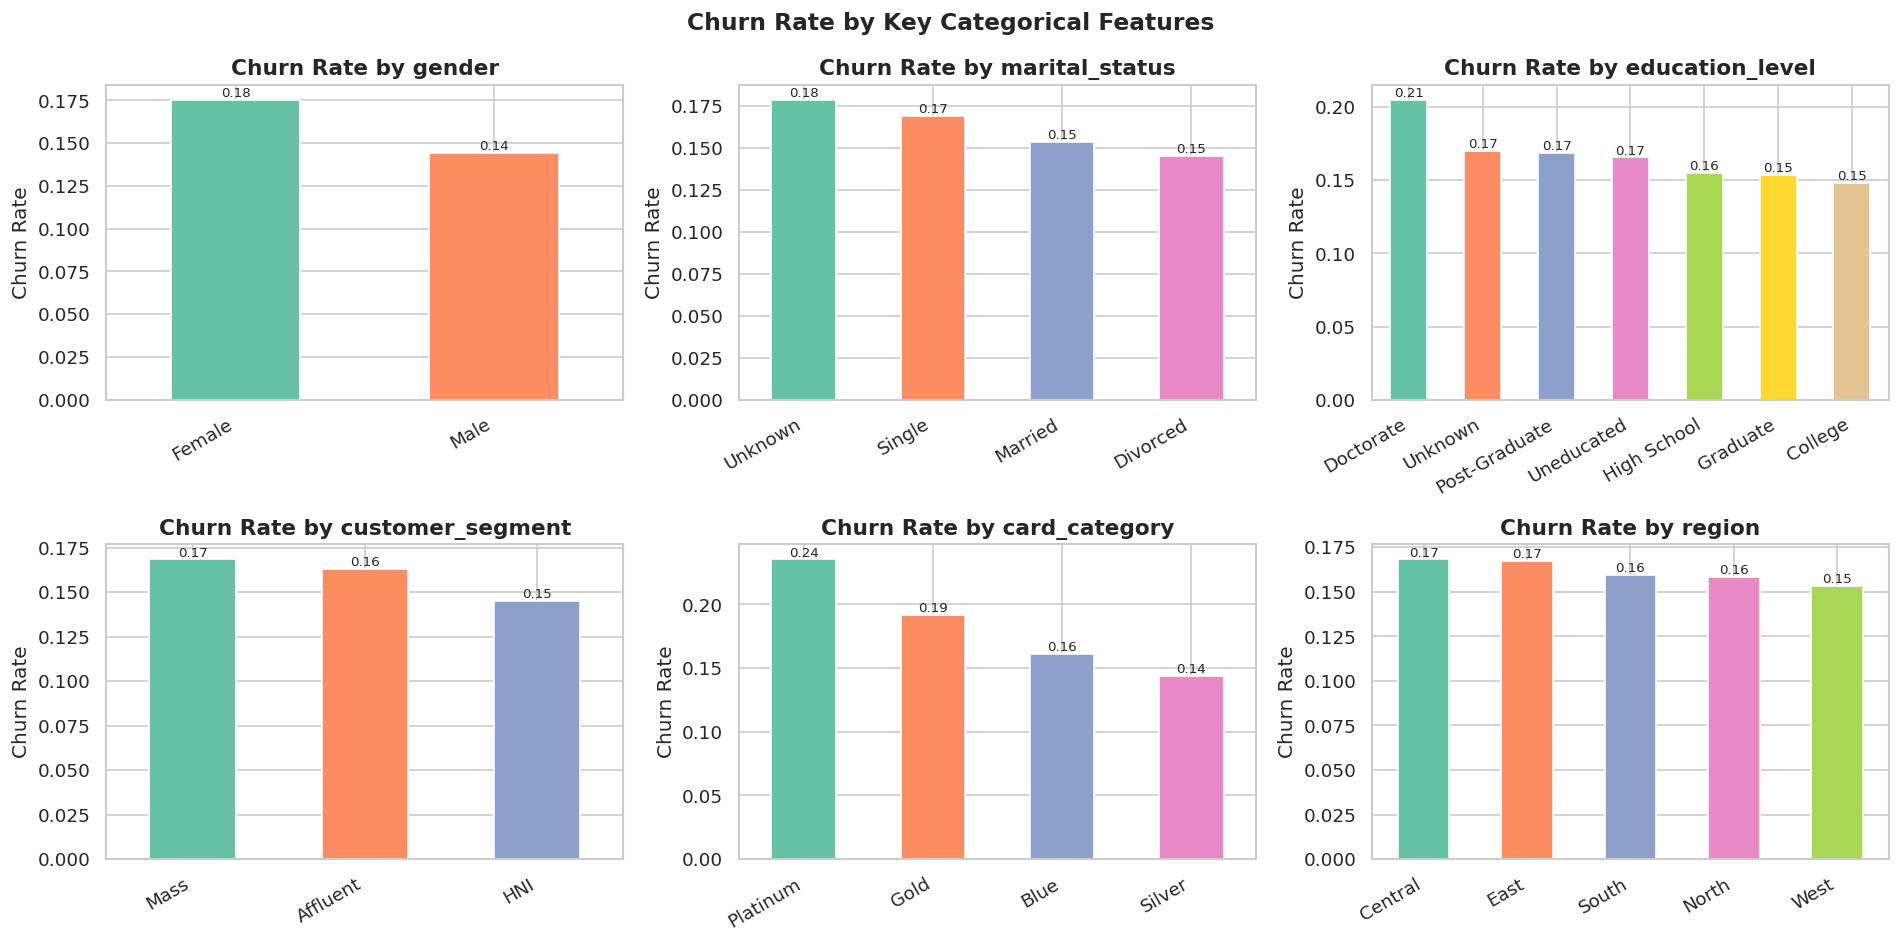

In [ ]:
# ── 3c. Categorical features vs Churn ────────────────────────────────────
top_cats = ['gender', 'marital_status', 'education_level',
            'customer_segment', 'card_category', 'region']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2'),
                   edgecolor='white', linewidth=1)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    for bar in axes[i].patches:
        axes[i].annotate(f'{bar.get_height():.2f}',
                         (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha='center', va='bottom', fontsize=8)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# HeatMap

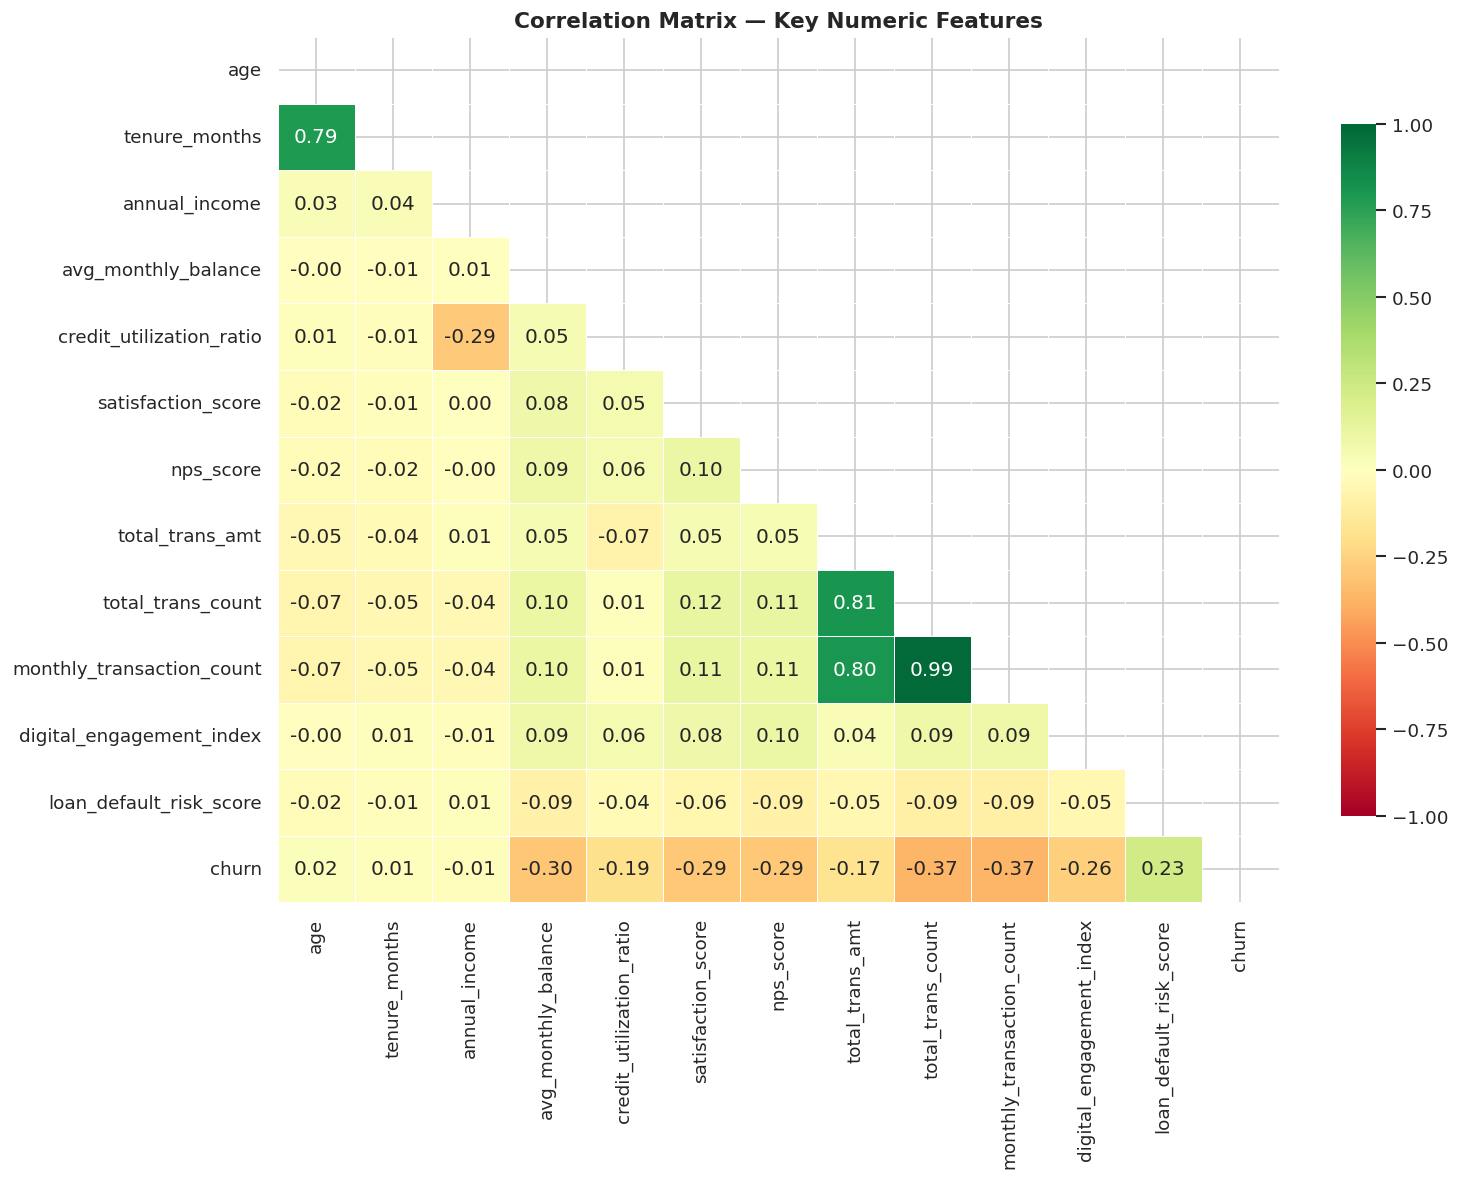

In [ ]:
# ── 3d. Correlation heatmap (key numeric features) ────────────────────────
key_num = ['age', 'tenure_months', 'annual_income', 'avg_monthly_balance',
           'credit_utilization_ratio', 'satisfaction_score', 'nps_score',
           'total_trans_amt', 'total_trans_count', 'monthly_transaction_count',
           'digital_engagement_index', 'loan_default_risk_score', 'churn']

plt.figure(figsize=(13, 10))
corr = df[key_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Key Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Boxplots

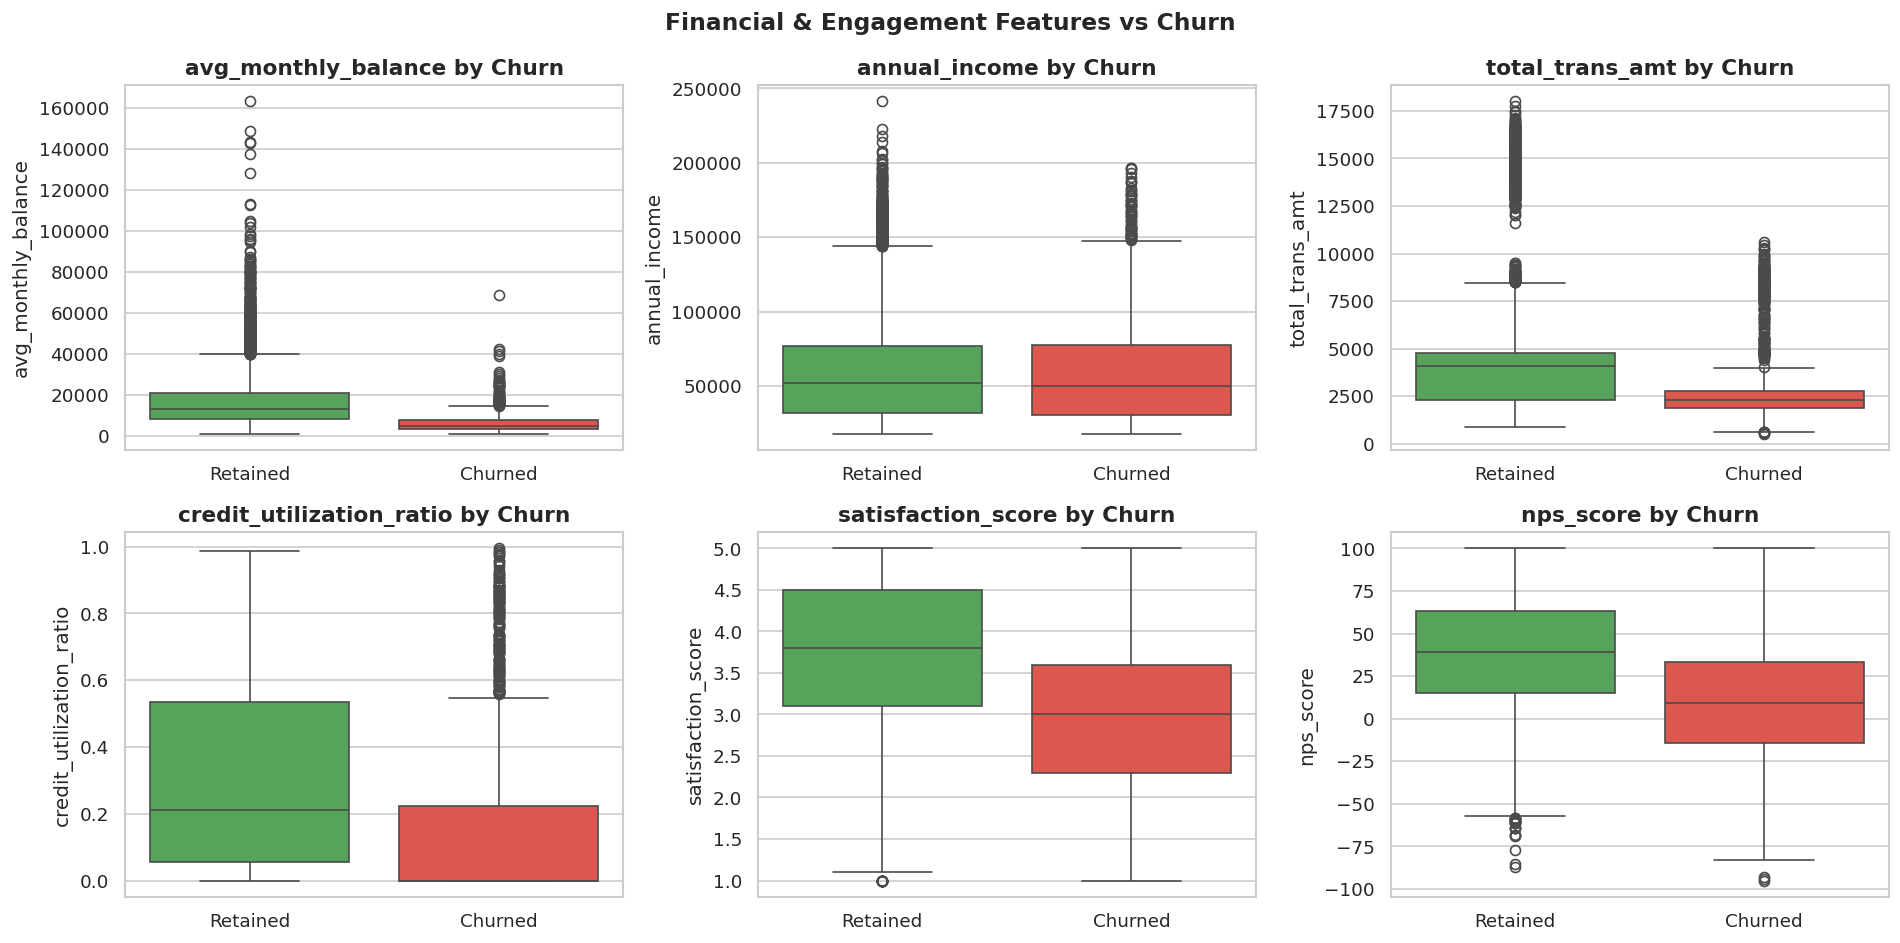

In [ ]:
# ── 3e. Boxplots — financial features by Churn ───────────────────────────
fin_features = ['avg_monthly_balance', 'annual_income', 'total_trans_amt',
                'credit_utilization_ratio', 'satisfaction_score', 'nps_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(fin_features):
    sns.boxplot(data=df, x='churn', y=feat, palette=['#4CAF50', '#F44336'],
                ax=axes[i])
    axes[i].set_title(f'{feat} by Churn', fontweight='bold')
    axes[i].set_xticklabels(['Retained', 'Churned'])
    axes[i].set_xlabel('')

plt.suptitle('Financial & Engagement Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Handling Missing Values

In [ ]:
print('Missing values BEFORE:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# app_rating_given — 56% missing → fill with median (ordinal scale 1-5)
df['app_rating_given'] = df['app_rating_given'].fillna(
    df['app_rating_given'].median())

# Generic fallback for any other numeric nulls → median
remaining_num_nulls = df.select_dtypes(include=np.number).columns[
    df.select_dtypes(include=np.number).isnull().any()]
for col in remaining_num_nulls:
    df[col] = df[col].fillna(df[col].median())

# Categorical nulls → mode
remaining_cat_nulls = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()]
for col in remaining_cat_nulls:
    df[col] = df[col].fillna(df[col].mode()[0])

print('\nMissing values AFTER:', df.isnull().sum().sum())
print('✅ All missing values handled.')

Missing values BEFORE:
Series([], dtype: int64)

Missing values AFTER: 0
✅ All missing values handled.


# Removing Duplicate Data ❌❌

# Fixing Incorrect Data

In [ ]:
# ── Age: Valid banking customer range 18–90 ───────────────────────────────
invalid_age = ((df['age'] < 18) | (df['age'] > 90)).sum()
print(f'Invalid age values (< 18 or > 90): {invalid_age}')
df['age'] = df['age'].clip(lower=18, upper=90)

# ── Tenure: Cannot be negative ────────────────────────────────────────────
invalid_tenure = (df['tenure_months'] < 0).sum()
print(f'Negative tenure values: {invalid_tenure}')
df['tenure_months'] = df['tenure_months'].clip(lower=0)

# ── Credit utilisation: Must be 0–1 (ratio) ──────────────────────────────
invalid_cr = ((df['credit_utilization_ratio'] < 0) |
              (df['credit_utilization_ratio'] > 1)).sum()
print(f'Invalid credit_utilization_ratio values: {invalid_cr}')
df['credit_utilization_ratio'] = df['credit_utilization_ratio'].clip(0, 1)

# ── Satisfaction / NPS: Enforce valid ranges ──────────────────────────────
df['satisfaction_score'] = df['satisfaction_score'].clip(1, 5)
df['nps_score']           = df['nps_score'].clip(0, 10)

# ── Binary flag columns: Must be 0 or 1 ──────────────────────────────────
flag_cols = [c for c in df.columns if c.endswith('_flag')]
for col in flag_cols:
    bad = (~df[col].isin([0, 1])).sum()
    if bad > 0:
        print(f'  {col}: {bad} invalid flag values → set to 0')
        df[col] = df[col].where(df[col].isin([0, 1]), 0)

print('\n✅ Incorrect data fixed.')

Invalid age values (< 18 or > 90): 0
Negative tenure values: 0
Invalid credit_utilization_ratio values: 0

✅ Incorrect data fixed.


# Handling Outliers

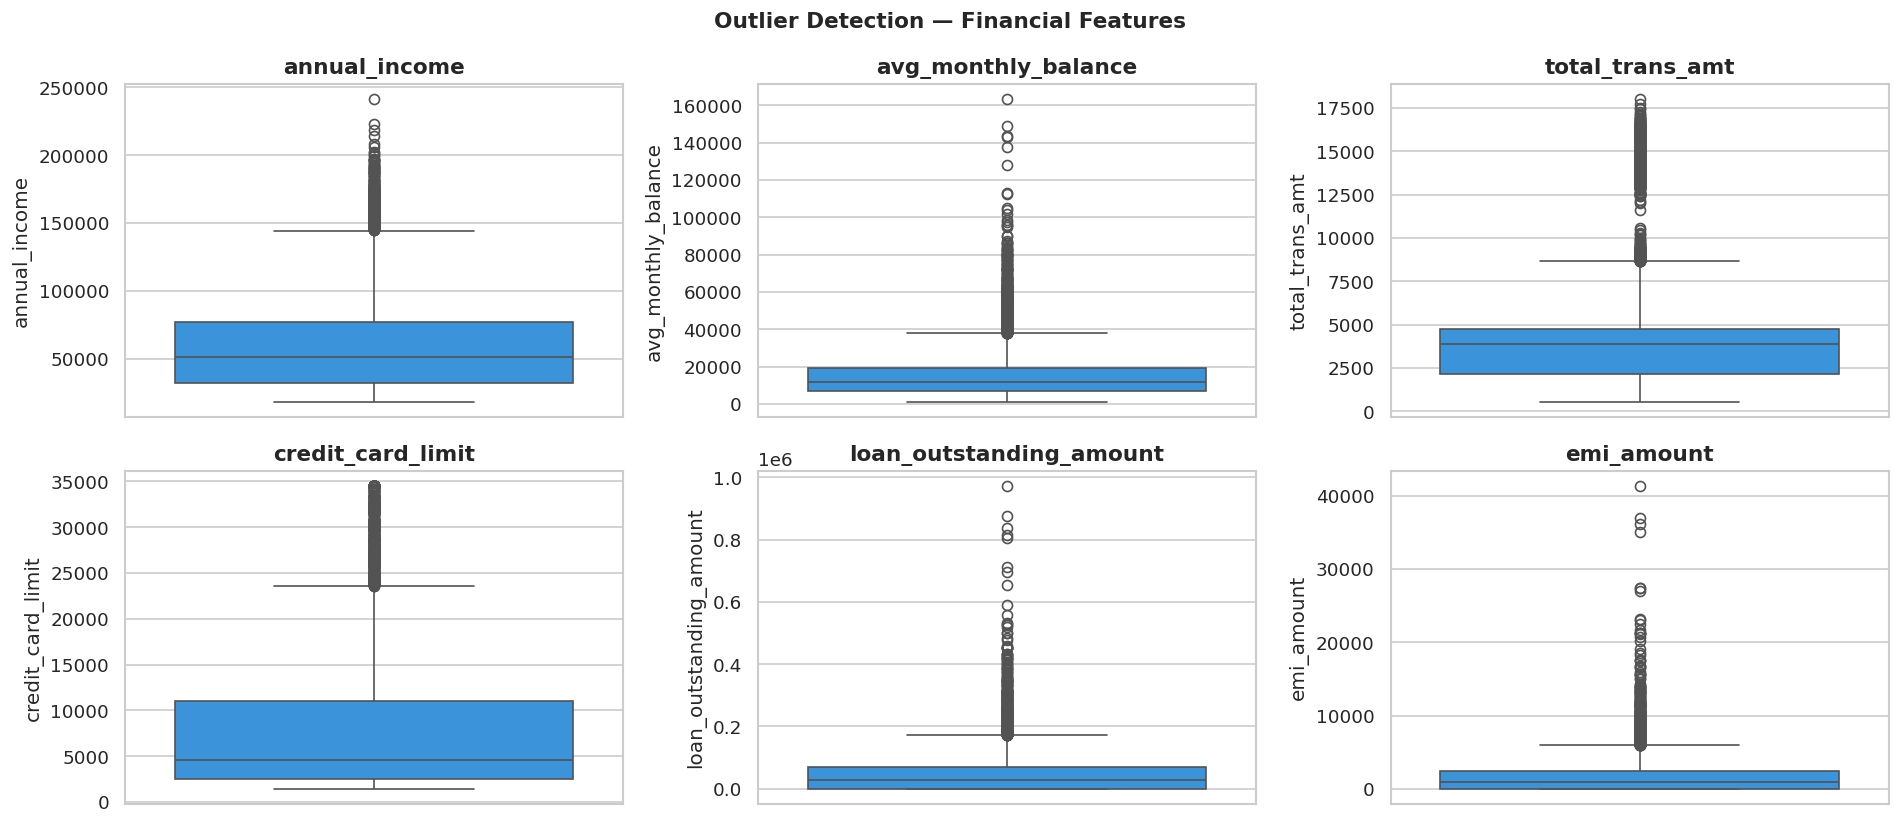

In [ ]:
# ── Visualise outliers in key financial columns ───────────────────────────
outlier_cols = ['annual_income', 'avg_monthly_balance', 'total_trans_amt',
                'credit_card_limit', 'loan_outstanding_amount', 'emi_amount']

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#2196F3')
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Outlier Detection — Financial Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR Capping

In [ ]:
# ── IQR Capping (Winsorisation at 1.5×IQR) ───────────────────────────────
def cap_outliers_iqr(dataframe, column):
    """Cap values below Q1-1.5*IQR and above Q3+1.5*IQR."""
    Q1  = dataframe[column].quantile(0.25)
    Q3  = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((dataframe[column] < lower) | (dataframe[column] > upper)).sum()
    dataframe[column] = dataframe[column].clip(lower=lower, upper=upper)
    return n_outliers

print('Outliers capped (IQR method):')
for col in outlier_cols:
    n = cap_outliers_iqr(df, col)
    print(f'  {col:35s}: {n:4,} values capped')

print('\n✅ Outliers handled via IQR capping (Winsorisation).')

Outliers capped (IQR method):
  annual_income                      :  320 values capped
  avg_monthly_balance                :  462 values capped
  total_trans_amt                    :  704 values capped
  credit_card_limit                  :  784 values capped
  loan_outstanding_amount            :  405 values capped
  emi_amount                         :  455 values capped

✅ Outliers handled via IQR capping (Winsorisation).


# Z-Score method

In [ ]:
# ── Z-Score method (for reference — rows with |z| > 3 in any key col) ────
z_cols = ['annual_income', 'avg_monthly_balance', 'total_trans_amt']
z_scores = np.abs(stats.zscore(df[z_cols]))
extreme_rows = (z_scores > 3).any(axis=1).sum()
print(f'Rows with Z-score > 3 in key financial columns: {extreme_rows}')
print('(These are already addressed by IQR capping above.)')

Rows with Z-score > 3 in key financial columns: 0
(These are already addressed by IQR capping above.)


In [ ]:
df['customer_id'] = df['customer_id'].astype(str)
for col in flag_cols + ['churn','minimum_due_paid_flag','prepayment_flag',
                         'paperless_statement_enabled','retention_offer_received',
                         'retention_offer_accepted','discount_or_fee_waiver_received',
                         'relationship_manager_assigned','loyalty_program_member']:
    if col in df.columns: df[col] = df[col].astype('int8')
for col in [c for c in df.columns if 'count' in c]:
    df[col] = df[col].round().astype('int32')
print('✅ Data types converted.')

KeyError: 'customer_id'

In [ ]:
str_cols = df.select_dtypes(include='object').columns.tolist()
str_cols = [c for c in str_cols if c != 'customer_id']  # skip ID

for col in str_cols:
    df[col] = (df[col]
               .astype(str)
               .str.strip()          # remove leading/trailing spaces
               .str.lower()          # lowercase
               .str.replace(r'\s+', ' ', regex=True)  # collapse whitespace
               .str.replace(r'[^a-z0-9 _\-]', '', regex=True))  # remove special chars

print('Unique values after text standardisation:')
for col in str_cols[:6]:
    print(f'  {col}: {df[col].unique()}')
print('✅ Text standardised.')

Unique values after text standardisation:
  gender: ['female' 'male']
  marital_status: ['married' 'single' 'divorced' 'unknown']
  education_level: ['unknown' 'high school' 'graduate' 'uneducated' 'college' 'doctorate'
 'post-graduate']
  occupation_type: ['salaried' 'homemaker' 'retired' 'student' 'business owner'
 'self-employed']
  income_band: ['low' 'middle' 'upper-middle' 'high' 'lower-middle']
  income_category: ['less than 40k' '60k - 80k' '80k - 120k' '120k ' '40k - 60k' 'unknown']
✅ Text standardised.


In [ ]:
cat_cols_remaining = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols_remaining}')

# ── Binary / ordinal columns → Label Encoding ────────────────────────────
ordinal_cols = ['income_band', 'city_tier', 'education_level']

le = LabelEncoder()
le_mapping = {}
for col in ordinal_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
        le_mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('\nLabel encoding mappings:')
for col, mapping in le_mapping.items():
    print(f'  {col}: {mapping}')

# ── Nominal columns → One-Hot Encoding ───────────────────────────────────
nominal_cols = [c for c in cat_cols_remaining if c not in ordinal_cols]
print(f'\nNominal columns for One-Hot Encoding: {nominal_cols}')

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype='int8')
print(f'\nShape after encoding: {df.shape}')
print('✅ Categorical data encoded.')

Categorical columns to encode: ['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']

Label encoding mappings:
  income_band: {'high': np.int64(0), 'low': np.int64(1), 'lower-middle': np.int64(2), 'middle': np.int64(3), 'upper-middle': np.int64(4)}
  city_tier: {'tier 1': np.int64(0), 'tier 2': np.int64(1), 'tier 3': np.int64(2)}
  education_level: {'college': np.int64(0), 'doctorate': np.int64(1), 'graduate': np.int64(2), 'high school': np.int64(3), 'post-graduate': np.int64(4), 'uneducated': np.int64(5), 'unknown': np.int64(6)}

Nominal columns for One-Hot Encoding: ['gender', 'marital_status', 'occupation_type', 'income_category', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'com

In [ ]:
# ── 1. Drop unique identifier ─────────────────────────────────────────────
drop_cols = ['customer_id']

# ── 2. Drop near-zero-variance columns ───────────────────────────────────
num_df  = df.drop(columns=drop_cols + ['churn'], errors='ignore').select_dtypes(include=np.number)
low_var = num_df.columns[(num_df.std() < 0.01)].tolist()
print(f'Near-zero variance columns: {low_var}')
drop_cols += low_var

# ── 3. Drop highly correlated redundant features (|r| > 0.95) ────────────
corr_matrix = num_df.drop(columns=low_var, errors='ignore').corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'Highly correlated (>0.95) columns to drop: {high_corr}')
drop_cols += high_corr

df.drop(columns=drop_cols, inplace=True, errors='ignore')
print(f'\nShape after removing irrelevant columns: {df.shape}')
print('✅ Irrelevant columns removed.')

Near-zero variance columns: []
Highly correlated (>0.95) columns to drop: ['total_trans_count', 'credit_card_limit', 'emi_amount']

Shape after removing irrelevant columns: (8101, 87)
✅ Irrelevant columns removed.


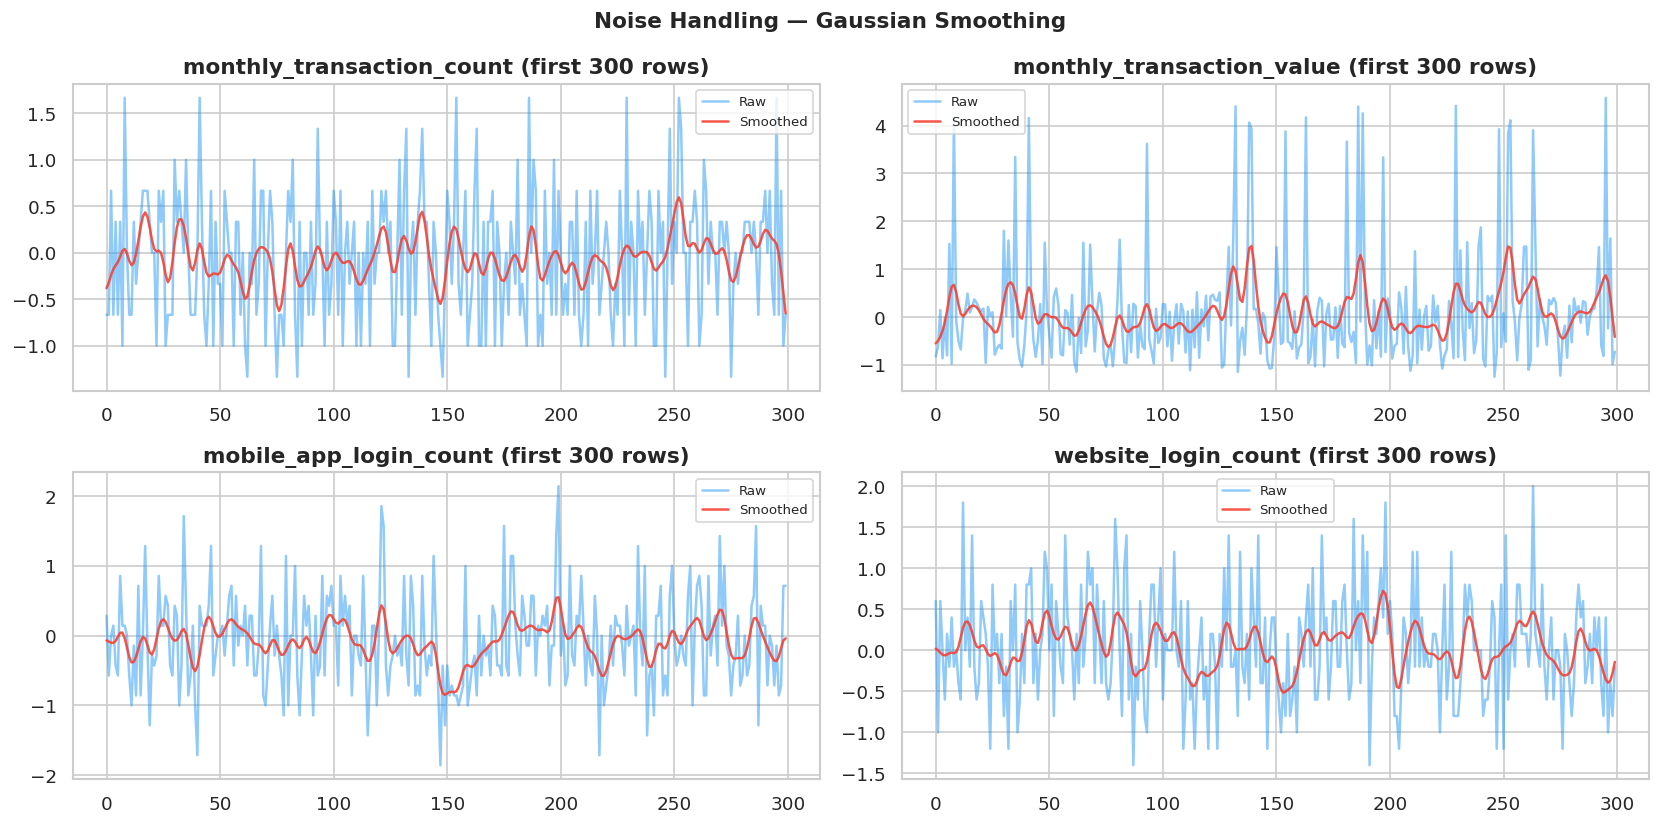

In [ ]:
# ── Method 1: Gaussian Smoothing on noisy time-series-like columns ────────
noisy_cols = ['monthly_transaction_count', 'monthly_transaction_value',
              'mobile_app_login_count', 'website_login_count']

from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(noisy_cols):
    if col in X_final.columns:
        raw      = X_final[col].values
        smoothed = gaussian_filter1d(raw, sigma=2)
        axes[i].plot(raw[:300],      alpha=0.5, label='Raw',      color='#2196F3')
        axes[i].plot(smoothed[:300], alpha=0.9, label='Smoothed', color='#F44336', lw=1.5)
        axes[i].set_title(f'{col} (first 300 rows)', fontweight='bold')
        axes[i].legend(fontsize=8)

plt.suptitle('Noise Handling — Gaussian Smoothing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Method 2: Rolling-mean smoothing ─────────────────────────────
for col in noisy_cols:
    if col in X_scaled.columns:                      # ← was X_final, now X_scaled
        X_scaled[col + '_smoothed'] = (
            X_scaled[col].rolling(window=5, min_periods=1, center=True).mean()
        )

print('✅ Noise handled via Gaussian smoothing & rolling mean.')
print(f'Final feature matrix shape: {X_scaled.shape}')

✅ Noise handled via Gaussian smoothing & rolling mean.
Final feature matrix shape: (8101, 120)


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟣 NEW  STEP 1 — Identify the target column
# ════════════════════════════════════════════════════════════════════
TARGET = 'churn'
print(f'🎯 Target column  : {TARGET}')
print(f'   Classes        : {sorted(df[TARGET].unique())}')
print(f'   Distribution   :')
print(df[TARGET].value_counts().to_string())

🎯 Target column  : churn
   Classes        : [np.int64(0), np.int64(1)]
   Distribution   :
churn
0    6799
1    1302


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟣 NEW  STEP 2 — Choose useful feature columns
# ════════════════════════════════════════════════════════════════════
# Select all columns that are NOT the target
all_features = [c for c in X_scaled.columns]
print(f'📌 Total features available : {len(all_features)}')

# Keep high-information features — drop very low variance ones
feature_variance = X_scaled.var()
useful_features  = feature_variance[feature_variance > 0.001].index.tolist()
print(f'✅ Useful features selected  : {len(useful_features)}')
print(f'   Dropped (near-zero var)   : {len(all_features) - len(useful_features)}')

📌 Total features available : 116
✅ Useful features selected  : 116
   Dropped (near-zero var)   : 0


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟣 NEW  STEP 3 — Remove unnecessary columns (IDs / leakage risk)
# ════════════════════════════════════════════════════════════════════
# customer_id already removed in Step 5.3
# Confirm no ID-like columns remain
id_like = [c for c in useful_features if 'id' in c.lower() or 'index' in c.lower()]
print(f'ID-like columns still present: {id_like}')
if id_like:
    useful_features = [c for c in useful_features if c not in id_like]
    print(f'Removed — remaining: {len(useful_features)} features')
else:
    print('✅ No ID/irrelevant columns remain.')

ID-like columns still present: ['digital_engagement_index']
Removed — remaining: 115 features


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟣 NEW  STEP 5 — Encode any remaining categoricals (verification)
# ════════════════════════════════════════════════════════════════════
remaining_obj = X.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print(f'⚠️  Remaining object columns: {remaining_obj}')
    for col in remaining_obj:
        X[col] = LabelEncoder().fit_transform(X[col])
    print('   → Label-encoded.')
else:
    print('✅ All features are numeric — no further encoding needed.')

✅ All features are numeric — no further encoding needed.


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟣 NEW  STEP 6 — Scale check (confirm scaling applied)
# ════════════════════════════════════════════════════════════════════
print('Feature value ranges (first 8 columns):')
print(X.iloc[:, :8].describe().loc[['min','max','mean','std']].T.round(3))
print('\n✅ Features are scaled — ranges look normalised.')

Feature value ranges (first 8 columns):
                      min    max   mean    std
age                -1.818  2.455  0.035  0.726
education_level    -1.000  5.000  1.601  1.698
dependent_count    -1.000  1.500  0.175  0.649
annual_income      -0.745  4.207  0.188  0.785
income_band        -1.000  4.000  0.419  1.564
city_tier           0.000  2.000  1.107  0.763
tenure_months      -2.875  2.500  0.001  0.992
number_of_products -1.500  1.000 -0.095  0.777

✅ Features are scaled — ranges look normalised.


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟠 NEW  STEP 8a — Train / Test Split
# ════════════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test  set : {X_test.shape[0]:,}  rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain churn rate : {y_train.mean()*100:.1f}%')
print(f'Test  churn rate : {y_test.mean()*100:.1f}%  (stratified = balanced splits ✅)')

Train set : 6,480 rows (80.0%)
Test  set : 1,621  rows (20.0%)

Train churn rate : 16.1%
Test  churn rate : 16.1%  (stratified = balanced splits ✅)


In [ ]:
# ════════════════════════════════════════════════════════════════════
# 🟠 NEW  STEP 8b — Train Model (Random Forest Classifier)
# ════════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
import time

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',   # handles the ~16% churn imbalance
    random_state=42,
    n_jobs=-1
)

start = time.time()
model.fit(X_train, y_train)
elapsed = time.time() - start

print(f'✅ RandomForestClassifier trained in {elapsed:.1f}s')
print(f'   Trees      : {model.n_estimators}')
print(f'   Max depth  : {model.max_depth}')
print(f'   Features   : {model.n_features_in_}')

✅ RandomForestClassifier trained in 4.3s
   Trees      : 150
   Max depth  : 12
   Features   : 115
